# Notebook 0: Theory and Applications. Approach to the problem

## 0.1) Theory behing the Mousetrap problem
The core idea is that there is a big box filled with mousetraps where two balls are balanced on it. A ball is thrown at random cuch that when it contacts the balls or mousetrap it makes the last clash down, making the other two rise up in the air and carry out a chain reaction.

### Applications of this chain reaction
This type of chain reaction can be used to model many different systems:
- Nuclear fission
- Epidemology (spread of diseases)
- Population dynamics
- Wildfire propagations (mousetraps are trees and ping-pong balls are burning ember)

### Different states possible if a discrete approach is taken
Taking a discrete approach to the problem, then the possible space is divided into cells of the same size and they can take up four distinct states. A cell can be inert, meaning it does not interact with the evolution of the system, it can be armed, meaning it will contribute to the evolution in the next timestep, it can be active, which is what happens to armed cells in the next timestep, and they can be dead, which is what happend to firing cells in the next timestep.

## 0.2) Approach to the problem
A simplified way of modelling this could be that we have an array that is divided into cells which are in state zero, but randomly one of them is flipped to one and there is a probability taht that one state will. ake nighboring cells also turn to one with a probabiulity that is inversely proportional to the distance to the distance to the one state. This is attempted with the following function:

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

In [2]:
import numpy as np

def simulate_MT_dynamics(rho, p0, kernel='exp', r0=3.0, L=50, steps=200, rng=None):
    rng = rng or np.random.default_rng()
    grid = (rng.random((L, L)) < rho).astype(int)      # 1 = armed trap present, 0 = empty
    state = np.where(grid == 1, 0, -1)                  # 0=armed, 1=fired, -1=no trap
    ys, xs = np.where(grid == 1)
    seed = rng.integers(len(xs))
    state[ys[seed], xs[seed]] = 1 

    # This block defines a grid where -1 means it is permamently inert
    #, 0 means it is armed, 1 means it fired this generation and -2 means it
    # previously fired

    def p_of_d(d):
        if kernel == 'exp': # This is a type of evolution that evolves exponentially, symbolizing a characteristic exponential decay
            return p0 * np.exp(-d / r0)
        elif kernel == 'inv': # This describes a second type of evolution where there is a distinct distance cutoff
            return np.minimum(p0 / np.maximum(d, 1), 1.0) * (d <= r0)

    # This block taked a numpy array of distances and converts it into a 
    # triggering probability

    for t in range(steps):
        fired = np.argwhere(state == 1)
        if len(fired) == 0:
            break #If there are no active firers, then the system will not change and the current timestep
            # will be outputted
        armed = np.argwhere(state == 0)
        if len(armed) == 0:
            break # Same concept as before, if all the cells have shot out, then 
            # the system will remain constant and the current timestep will be outputted
        for fy, fx in fired:
            d = np.hypot(armed[:,0]-fy, armed[:,1]-fx) # distance from armed cell to taget cell
            hits = rng.random(len(d)) < p_of_d(d) # just a probability
            for (ay, ax) in armed[hits]:
                state[ay, ax] = 1
        state[state == 1] = np.where(rng.random(np.sum(state==1)) < 1, 2, 1)  # mark spent
        state[state == 2] = -2  # spent, distinct from empty
    return state # This is the code that takes care of the actual evolution of the system.
    # The output of the function is the state after the given number of timesteps

print(simulate_MT_dynamics(0.1, 0.1))

[[-1 -1 -1 ... -1 -1 -1]
 [-1 -1 -1 ... -1 -1 -1]
 [-1 -1 -1 ... -1 -1 -1]
 ...
 [-1 -1 -1 ... -1 -1 -1]
 [-1 -1 -1 ... -1 -1 -1]
 [-1 -1 -1 ...  0 -1 -1]]


### Look at how different proportins of the inital conditions change the system

### Far away cells can be affected by the mousetrap or the ball moving - Look into this: All of the cells should be active, code in the two interactions (short and long range)

### Parameter that controls the density of the empty space

It is convenient to store all the information of the evolution of a system inside a list of arrays so that we can then extract it in subsequent functions with varied uses: 

In [3]:
def history_MT_dynamics(rho, p0, kernel='exp', r0=3.0, L=50, steps=200, rng=None):
    rng = rng or np.random.default_rng()
    grid = (rng.random((L, L)) < rho).astype(int)      # 1 = armed trap present, 0 = empty
    state = np.where(grid == 1, 0, -1)                  # 0=armed, 1=fired, -1=no trap
    ys, xs = np.where(grid == 1)
    seed = rng.integers(len(xs))
    state[ys[seed], xs[seed]] = 1 
    # This block defines a grid where -1 means it is permamently inert
    #, 0 means it is armed, 1 means it fired this generation and -2 means it
    # previously fired

    history = [state.copy()]  # record initial state as frame 0

    def p_of_d(d):
        if kernel == 'exp': # This is a type of evolution that evolves exponentially, symbolizinf a characteristic exponential decay
            return p0 * np.exp(-d / r0)
        elif kernel == 'inv': # This describes a second type of evolution where there is a distinct distance cutoff
            return np.minimum(p0 / np.maximum(d, 1), 1.0) * (d <= r0)
    # This block taked a numpy array of distances and converts it into a 
    # triggering probability

    for t in range(steps):
        fired = np.argwhere(state == 1)
        if len(fired) == 0:
            break #If there are no active firers, then the system will not change and the current timestep
            # will be outputted
        armed = np.argwhere(state == 0)
        if len(armed) == 0:
            break # Same concept as before, if all the cells have shot out, then 
            # the system will remain constant and the current timestep will be outputted
        newly_hit = np.zeros(len(armed), dtype=bool)
        for fy, fx in fired:
            d = np.hypot(armed[:,0]-fy, armed[:,1]-fx) # distance from armed cell to taget cell
            newly_hit |= rng.random(len(d)) < p_of_d(d) # just a probability
        for (ay, ax) in armed[newly_hit]:
            state[ay, ax] = 1
        # spend only the cells that were already fired BEFORE this step
        # (not the ones freshly hit above — they get to fire next round)
        for fy, fx in fired:
            state[fy, fx] = -2

        history.append(state.copy())  # record this generation

    return history

In [4]:
hist = history_MT_dynamics(rho=0.4, p0=0.8, kernel='exp', r0=3.0, steps=300)

The following will be a function that extracts a timestep inside the evolution of a system and plots it on the grid, where white or blanck cells are inert, yellow are armed, red are firing and black means died out: 

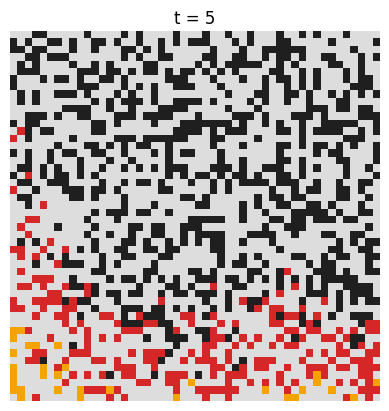

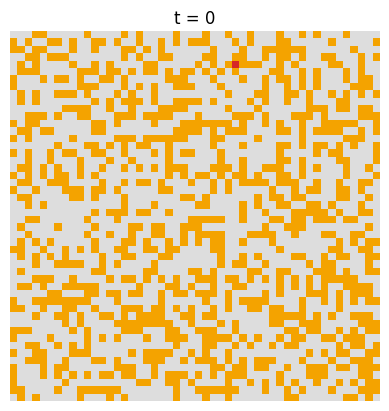

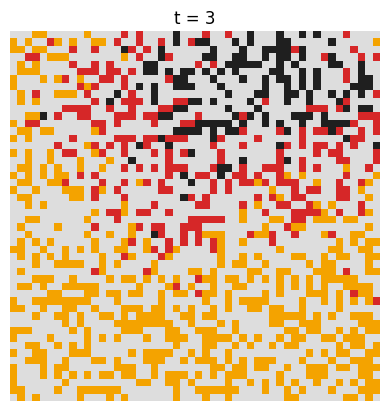

In [5]:
def show_timestep(history, t):
    """Display the grid state at timestep t from a history list."""
    if t < 0 or t >= len(history):
        raise ValueError(f"t={t} out of range; history has {len(history)} frames (0 to {len(history)-1})")

    state = history[t]

    # remap -1,0,1,-2 -> 0,1,2,3 for consistent coloring
    remap = {-1: 0, 0: 1, 1: 2, -2: 3}
    frame = np.vectorize(remap.get)(state)
    cmap = plt.matplotlib.colors.ListedColormap(
        ['#dddddd', '#f4a300', '#d62728', '#1f1f1f']  # inert, armed, firing, spent
    )

    fig, ax = plt.subplots()
    ax.imshow(frame, cmap=cmap, vmin=0, vmax=3)
    ax.set_title(f't = {t}')
    ax.axis('off')
    plt.show()

show_timestep(hist, 5)

show_timestep(hist, 0)

show_timestep(hist, 3)

Here, we animate the entire evolution:

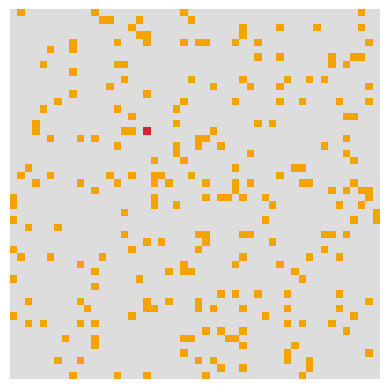

In [6]:
def animate_history(history, interval=150):
    remap = {-1: 0, 0: 1, 1: 2, -2: 3}
    cmap = plt.matplotlib.colors.ListedColormap(['#dddddd', '#f4a300', '#d62728', '#1f1f1f'])
    frames = [np.vectorize(remap.get)(f) for f in history]
    fig, ax = plt.subplots()
    im = ax.imshow(frames[0], cmap=cmap, vmin=0, vmax=3)
    ax.axis('off')
    def update(i):
        im.set_data(frames[i])
        ax.set_title(f't={i}')
        return [im]
    return FuncAnimation(fig, update, frames=len(frames), interval=interval, blit=False)

hist = history_MT_dynamics(0.1, 0.1)
anim = animate_history(hist)
plt.show()

And finally, we plot the number of cells at each of the possible four states as a function of time:

Cascade ran for 7 frames


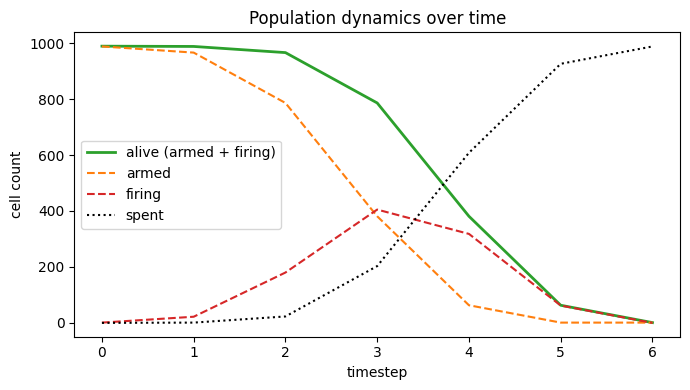

In [7]:
def plot_alive(history):
    """
    Plots counts of armed, firing, and spent cells at each timestep.
    'Alive' = armed (0) + firing (1); adjust as needed.
    """
    armed_counts  = [np.sum(s == 0)  for s in history]
    firing_counts = [np.sum(s == 1)  for s in history]
    spent_counts  = [np.sum(s == -2) for s in history]
    alive_counts  = [a + f for a, f in zip(armed_counts, firing_counts)]

    t = np.arange(len(history))

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(t, alive_counts, label='alive (armed + firing)', color='tab:green', lw=2)
    ax.plot(t, armed_counts, label='armed', color='tab:orange', ls='--')
    ax.plot(t, firing_counts, label='firing', color='tab:red', ls='--')
    ax.plot(t, spent_counts, label='spent', color='black', ls=':')
    ax.set_xlabel('timestep')
    ax.set_ylabel('cell count')
    ax.set_title('Population dynamics over time')
    ax.legend()
    plt.tight_layout()
    plt.show()

hist_dynamics = history_MT_dynamics(rho=0.4, p0=0.8, kernel='exp', r0=3.0, steps=300)
print(f"Cascade ran for {len(hist_dynamics)} frames")
plot_alive(hist_dynamics)

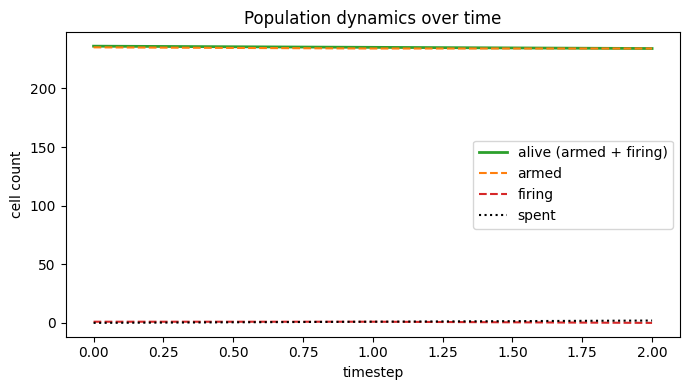

In [8]:
plot_alive(hist)

## 0.3) Modeling and short and long range interactions

Taking the mousetrap analogy, a nearby mousetrap can be activated by either the ball or the previously activated mousetrap, in our previous functions, we had only incorporated short range (mousetrap) interactions.

To incorporate long term interactions we have to identify another activation parameter with a probability of activation that increases as the distance increases until reaching a theoretical optimal point after which the probabiloty fo activation dies down exponentially.

We assume that the probabiloty increase and the increase in distance at short ranges is also exponential.

In this case, we will just have to take the original dynamics function and add this new term of activation:

In [ ]:
import numpy as np

def p_ball_of_d(d, p0_ball, d_opt, r_rise, r_fall): # Long range kernel
    d = np.asarray(d, dtype=float)
    rising = d <= d_opt
    return np.where(
        rising,
        p0_ball * np.exp(-(d_opt - d) / r_rise),   # 0 -> p0_ball as d -> d_opt
        p0_ball * np.exp(-(d - d_opt) / r_fall)     # p0_ball -> 0 as d grows past d_opt
    )

def p_trap_of_d(d, p0_trap, r0_trap): # Short range kernel
    return p0_trap * np.exp(-d / r0_trap)

def _combined_p_of_d(d, p0_trap, r0_trap, p0_ball, d_opt, r_rise, r_fall): # Calculates the probability associated
    # with both kernels
    p_trap = p_trap_of_d(d, p0_trap, r0_trap)
    p_ball = p_ball_of_d(d, p0_ball, d_opt, r_rise, r_fall)
    return 1 - (1 - p_trap) * (1 - p_ball)


def simulate_MT_dynamics_v2(rho, p0_trap, r0_trap,
                             p0_ball, d_opt, r_rise, r_fall,
                             L=50, steps=200, rng=None): # This is the original dynamics function but the probability is now
    # the conjoined probability
    rng = rng or np.random.default_rng()
    grid = (rng.random((L, L)) < rho).astype(int)
    state = np.where(grid == 1, 0, -1)
    ys, xs = np.where(grid == 1)
    seed = rng.integers(len(xs))
    state[ys[seed], xs[seed]] = 1

    for t in range(steps):
        fired = np.argwhere(state == 1)
        if len(fired) == 0:
            break
        armed = np.argwhere(state == 0)
        if len(armed) == 0:
            break

        newly_hit = np.zeros(len(armed), dtype=bool)
        for fy, fx in fired:
            d = np.hypot(armed[:, 0] - fy, armed[:, 1] - fx)
            p_total = _combined_p_of_d(d, p0_trap, r0_trap, p0_ball, d_opt, r_rise, r_fall)
            newly_hit |= rng.random(len(d)) < p_total

        for (ay, ax) in armed[newly_hit]:
            state[ay, ax] = 1
        for fy, fx in fired:
            state[fy, fx] = -2

    return state


def history_MT_dynamics_v2(rho, p0_trap, r0_trap,
                            p0_ball, d_opt, r_rise, r_fall,
                            L=50, steps=200, rng=None):
    rng = rng or np.random.default_rng()
    grid = (rng.random((L, L)) < rho).astype(int)
    state = np.where(grid == 1, 0, -1)
    ys, xs = np.where(grid == 1)
    seed = rng.integers(len(xs))
    state[ys[seed], xs[seed]] = 1

    history = [state.copy()]

    for t in range(steps):
        fired = np.argwhere(state == 1)
        if len(fired) == 0:
            break
        armed = np.argwhere(state == 0)
        if len(armed) == 0:
            break

        newly_hit = np.zeros(len(armed), dtype=bool)
        for fy, fx in fired:
            d = np.hypot(armed[:, 0] - fy, armed[:, 1] - fx)
            p_total = _combined_p_of_d(d, p0_trap, r0_trap, p0_ball, d_opt, r_rise, r_fall)
            newly_hit |= rng.random(len(d)) < p_total

        for (ay, ax) in armed[newly_hit]:
            state[ay, ax] = 1
        for fy, fx in fired:
            state[fy, fx] = -2

        history.append(state.copy())

    return history

Let's plot the evolution of the different states of the cells and the grid at the first 5 timesteps for an arbitrary system:

In [13]:
hist = history_MT_dynamics(rho=0.9, p0=0.8, kernel='exp', r0=3.0, steps=300)

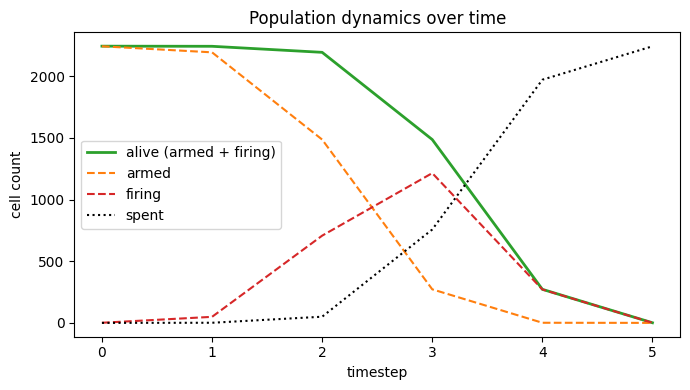

In [15]:
plot_alive(hist)

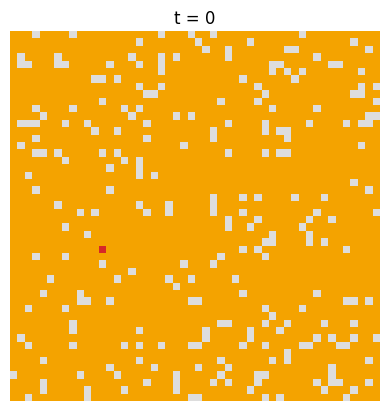

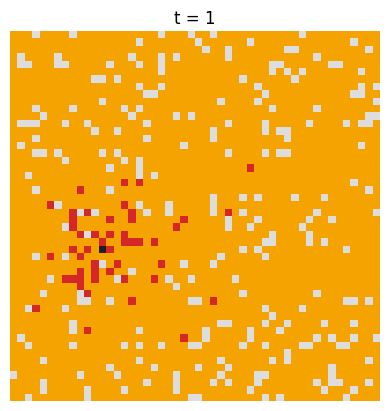

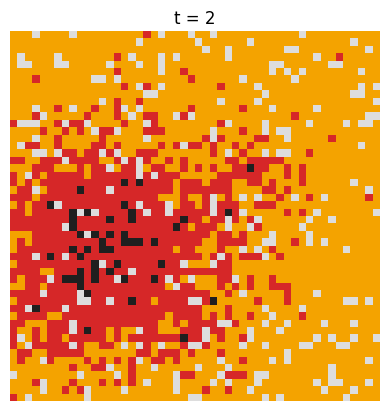

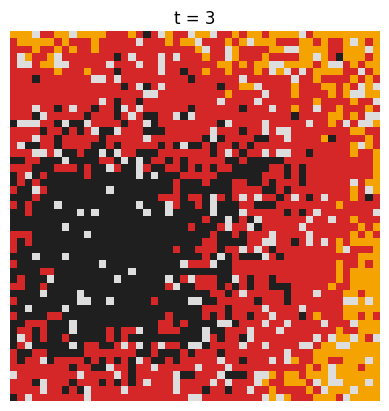

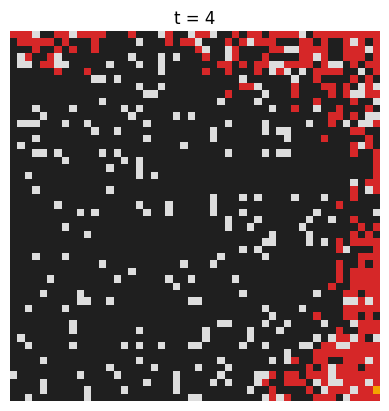

In [16]:
for i in range(5):
    show_timestep(hist, i)

## 0.4) Comparing short term, long term and conjoined interaction

### 0.4.1) Short term interaction

Here we'll define a function that only takes into account short term propagation, which is just the original dynamcis function:

In [ ]:
def short_term_interaction(rho, p0, kernel='exp', r0=3.0, L=50, steps=200, rng=None):
    rng = rng or np.random.default_rng()
    grid = (rng.random((L, L)) < rho).astype(int)      # 1 = armed trap present, 0 = empty
    state = np.where(grid == 1, 0, -1)                  # 0=armed, 1=fired, -1=no trap
    ys, xs = np.where(grid == 1)
    seed = rng.integers(len(xs))
    state[ys[seed], xs[seed]] = 1 

    # This block defines a grid where -1 means it is permamently inert
    #, 0 means it is armed, 1 means it fired this generation and -2 means it
    # previously fired

    def p_of_d(d):
        if kernel == 'exp': # This is a type of evolution that evolves exponentially, symbolizing a characteristic exponential decay
            return p0 * np.exp(-d / r0)
        elif kernel == 'inv': # This describes a second type of evolution where there is a distinct distance cutoff
            return np.minimum(p0 / np.maximum(d, 1), 1.0) * (d <= r0)

    # This block taked a numpy array of distances and converts it into a 
    # triggering probability

    for t in range(steps):
        fired = np.argwhere(state == 1)
        if len(fired) == 0:
            break #If there are no active firers, then the system will not change and the current timestep
            # will be outputted
        armed = np.argwhere(state == 0)
        if len(armed) == 0:
            break # Same concept as before, if all the cells have shot out, then 
            # the system will remain constant and the current timestep will be outputted
        for fy, fx in fired:
            d = np.hypot(armed[:,0]-fy, armed[:,1]-fx) # distance from armed cell to taget cell
            hits = rng.random(len(d)) < p_of_d(d) # just a probability
            for (ay, ax) in armed[hits]:
                state[ay, ax] = 1
        state[state == 1] = np.where(rng.random(np.sum(state==1)) < 1, 2, 1)  # mark spent
        state[state == 2] = -2  # spent, distinct from empty
    return state

### 0.4.2) Long term interaction

Here we define a dynamics function that only tjes into accout long term interaction, which is easy to do if we use the original probability functions, but this time the function takes the long-term probability instead of the conjoined probability as the true activation probability:

Things done:
- Explanation on the reaction-diffusion pdes
- Adapt the functions defines to incorporate short range interactions.
- 

- function to compute critical density, that depends on density
- start with lower densituy and heck if all tehc ells that decayed and itf not i increase density run it again and check again
- run itn a lot of times with the diferent valus above lik total areaor diff probabilities or compare critical density with different range or conjoined interactions

Plot:
- of percentagr of cells devayed vs density
- several versions of the same plto chabging para,ters we talked abot like probabiloty variables or wether we only used short and long term interactions becaus eonly one cell is being actoivatec so we cqn try activating multiple, or posotiuon of cell activated
- this is the main visualization nie to have for next time we use a plot of cells decayed and density